# Notebook 05 — LSTM Autoencoder

**TFG:** Electricity Consumption Anomaly Detection and FDI Attack Mitigation in Edge Computing

---

### Improvements over v3

| v3 issue | v4 fix |
|---|---|
| `mode='medium'` + `vi_res_abs` (14 features) | **`mode='full'` (17 features)** with a warm-up buffer |
| F1 calibration misses low-severity attacks | **F2 calibration** (prioritises recall) |
| OR expansion: a single positive window contaminates 60 timesteps, yielding ~50K false positives | **AVERAGE expansion**: each timestep score is the mean of the overlapping windows |
| No Metal GPU configuration | **Metal GPU** with memory growth enabled |

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, json, time, warnings

warnings.filterwarnings('ignore')
np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 12

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, LSTM, Dense, RepeatVector, TimeDistributed
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score, fbeta_score,
    precision_score, recall_score,
    average_precision_score, precision_recall_curve
)
import joblib

tf.random.set_seed(42)

# ── Metal GPU configuration ──
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f'Metal GPU: {gpus[0].name} (memory growth ON)')
    BATCH_SIZE = 512
else:
    print('CPU mode')
    BATCH_SIZE = 256

print(f'TensorFlow {tf.__version__} | numpy {np.__version__}')
print(f'Batch: {BATCH_SIZE}')
print('OK')


Metal GPU: /physical_device:GPU:0 (memory growth ON)
TensorFlow 2.18.1 | numpy 2.0.2
Batch: 512
OK


## 1. Loading Real Data

In [2]:
BASE_DIR = '/Volumes/Extreme Pro Particion 1TB/TFG/UCIrvine/'
DATA_DIR = os.path.join(BASE_DIR, 'data')

with open(os.path.join(DATA_DIR, 'pipeline_config.json')) as f:
    config = json.load(f)

FEATURE_COLS = config['feature_cols']
ATTACK_TYPES = config['attack_types']

df_train = pd.read_csv(os.path.join(DATA_DIR, 'train_clean.csv'),
                        index_col='datetime', parse_dates=True)
df_val   = pd.read_csv(os.path.join(DATA_DIR, 'val_with_attacks.csv'),
                        index_col='datetime', parse_dates=True)
df_test  = pd.read_csv(os.path.join(DATA_DIR, 'test_with_attacks.csv'),
                        index_col='datetime', parse_dates=True)

print('DATA LOADED (real UCI)')
print('=' * 65)
for nm, d in [('Train', df_train), ('Val', df_val), ('Test', df_test)]:
    n_atk = (d['label'] == 1).sum() if 'label' in d.columns else 0
    rng = f'{d.index.min().date()} -> {d.index.max().date()}'
    atk = f'  | {n_atk:,} attacks ({n_atk/len(d)*100:.1f}%)' if n_atk else ''
    print(f'  {nm:6s} {len(d):>10,} rows  {rng}{atk}')

DATA LOADED (real UCI)
  Train   1,300,061 rows  2006-12-16 -> 2009-06-09
  Val       144,452 rows  2009-06-09 -> 2009-09-20  | 21,739 attacks (15.0%)
  Test      604,999 rows  2009-09-20 -> 2010-11-26  | 96,717 attacks (16.0%)


## 2. Features and Scaling (`mode = full`, 17 features)

**v4 change:** we switch to `mode='full'` (17 features) with a warm-up buffer for the rolling
statistics. The previous setting (`mode='medium'` + `vi_res_abs`, 14 features) omitted the three
most discriminative features.

**RobustScaler + clip [-5, 5]:** RobustScaler centres on the median and scales by the IQR.
Features with a near-zero IQR (`Sub_metering_1`/`Sub_metering_2`) would otherwise produce values
of about +/-5000; clipping bounds them without sacrificing robustness.

In [3]:
def compute_features(df, mode='full'):
    '''Feature engineering, identical to NB02/NB03/NB04 for cross-model comparability.'''
    f = df[FEATURE_COLS].copy()
    f['VI_residual'] = (
        df['Global_active_power']
        - df['Voltage'] * df['Global_intensity'] / 1000.0
    )
    if mode in ('medium', 'full'):
        h = df.index.hour + df.index.minute / 60.0
        f['hour_sin'] = np.sin(2 * np.pi * h / 24)
        f['hour_cos'] = np.cos(2 * np.pi * h / 24)
        d = df.index.dayofweek
        f['dow_sin'] = np.sin(2 * np.pi * d / 7)
        f['dow_cos'] = np.cos(2 * np.pi * d / 7)
        f['gap_diff1'] = df['Global_active_power'].diff().fillna(0)
    if mode == 'full':
        f['vi_res_abs'] = f['VI_residual'].abs()
        f['vi_res_roll15_mean'] = f['vi_res_abs'].rolling(15, min_periods=1).mean()
        f['gap_intensity_ratio'] = (
            df['Global_active_power'] / (df['Global_intensity'] + 0.01)
        )
        sm_sum = df['Sub_metering_1'] + df['Sub_metering_2'] + df['Sub_metering_3']
        gap_wh = df['Global_active_power'] * 1000 / 60 + 1e-8
        f['sm_gap_ratio'] = np.clip(sm_sum / gap_wh, 0, 3)
    return f

# ── v4 change: switch to mode='full' (17 features) ──────────────────
# A warm-up buffer feeds the rolling stats so val/test match the training distribution.────
WARMUP = 30

X_train_df = compute_features(df_train, mode='full')

_val_buf = pd.concat([df_train.iloc[-WARMUP:], df_val])
_val_feat = compute_features(_val_buf, mode='full')
X_val_df  = _val_feat.iloc[WARMUP:]

_test_buf = pd.concat([df_val.iloc[-WARMUP:], df_test])
_test_feat = compute_features(_test_buf, mode='full')
X_test_df  = _test_feat.iloc[WARMUP:]

feat_names = list(X_train_df.columns)
n_features = len(feat_names)

# ── RobustScaler + clip to [-5, 5] (bounds near-zero-IQR features) ──
CLIP_RANGE = 5.0
scaler = RobustScaler()
X_train_scaled = np.clip(scaler.fit_transform(X_train_df.values), -CLIP_RANGE, CLIP_RANGE)
X_val_scaled   = np.clip(scaler.transform(X_val_df.values), -CLIP_RANGE, CLIP_RANGE)
X_test_scaled  = np.clip(scaler.transform(X_test_df.values), -CLIP_RANGE, CLIP_RANGE)

X_train_scaled = np.nan_to_num(X_train_scaled, nan=0.0).astype(np.float32)
X_val_scaled   = np.nan_to_num(X_val_scaled, nan=0.0).astype(np.float32)
X_test_scaled  = np.nan_to_num(X_test_scaled, nan=0.0).astype(np.float32)

y_val  = df_val['label'].values
y_test = df_test['label'].values

print(f'Features ({n_features}): {feat_names}')
print(f'Scaler: RobustScaler + clip [{-CLIP_RANGE}, {CLIP_RANGE}]')
print(f'Scaled: {X_train_scaled.shape} / {X_val_scaled.shape} / {X_test_scaled.shape}')
print()
print('Range per feature after scaling+clip:')
for j, fn in enumerate(feat_names):
    col = X_train_scaled[:, j]
    print(f'  {fn:30s}  [{col.min():.2f}, {col.max():.2f}]  mean={col.mean():.3f}')

Features (17): ['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3', 'VI_residual', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'gap_diff1', 'vi_res_abs', 'vi_res_roll15_mean', 'gap_intensity_ratio', 'sm_gap_ratio']
Scaler: RobustScaler + clip [-5.0, 5.0]
Scaled: (1300061, 17) / (144452, 17) / (604999, 17)

Range per feature after scaling+clip:
  Global_active_power             [-0.42, 5.00]  mean=0.419
  Global_reactive_power           [-0.53, 5.00]  mean=0.111
  Voltage                         [-4.13, 3.18]  mean=-0.045
  Global_intensity                [-0.46, 5.00]  mean=0.417
  Sub_metering_1                  [0.00, 5.00]  mean=0.225
  Sub_metering_2                  [0.00, 5.00]  mean=0.508
  Sub_metering_3                  [0.00, 1.82]  mean=0.363
  VI_residual                     [-5.00, 1.28]  mean=-0.197
  hour_sin                        [-0.71, 0.71]  mean=-0.000
  hour_cos                     

## 3. Sliding Windows

For training we use 60-minute windows with a step of 30 (50% overlap). This doubles the amount of
training data relative to a step of 60, giving the LSTM more context and a wider variety of
temporal alignments.

For validation and test we use a step of 1, for maximum detection granularity.

In [4]:
WINDOW_SIZE = 60  # one hour of minute-resolution data
TRAIN_STEP  = 30  # 50% overlap to double the training set

def create_windows(data, window_size, step):
    '''Build sliding windows; pre-allocate the output array to avoid per-window copies.'''
    n = len(data)
    starts = np.arange(0, n - window_size + 1, step)
    n_windows = len(starts)
    windows = np.empty((n_windows, window_size, data.shape[1]), dtype=data.dtype)
    for i, s in enumerate(starts):
        windows[i] = data[s:s + window_size]
    return windows, starts

def window_labels_vectorized(y, starts, window_size):
    '''A window is labelled positive if any timestep inside it is an attack.'''
    cum = np.concatenate([[0], np.cumsum(y)])
    window_sums = cum[starts + window_size] - cum[starts]
    return (window_sums > 0).astype(int)

def window_meta_fast(y_arr, attack_type_arr, severity_arr, episode_arr,
                     starts, window_size):
    n_windows = len(starts)
    types = np.empty(n_windows, dtype=object)
    sevs  = np.empty(n_windows, dtype=object)
    eps   = np.full(n_windows, -1, dtype=int)
    for i, s in enumerate(starts):
        chunk_y = y_arr[s:s+window_size]
        attacked_idx = np.where(chunk_y == 1)[0]
        if len(attacked_idx) > 0:
            idx = s + attacked_idx[0]
            types[i] = attack_type_arr[idx]
            sevs[i]  = severity_arr[idx]
            eps[i]   = episode_arr[idx]
        else:
            types[i] = 'none'
            sevs[i]  = 'none'
    return types, sevs, eps

# Pull metadata into numpy arrays (fall back to defaults when columns are absent)
val_atk_type = df_val['attack_type'].values if 'attack_type' in df_val.columns else np.full(len(df_val), 'none')
val_severity = df_val['severity'].values if 'severity' in df_val.columns else np.full(len(df_val), 'none')
val_episode  = df_val['episode_id'].values if 'episode_id' in df_val.columns else np.full(len(df_val), -1)

test_atk_type = df_test['attack_type'].values
test_severity = df_test['severity'].values
test_episode  = df_test['episode_id'].values

# Training: step=30 (50% overlap)
X_train_w, train_starts = create_windows(X_train_scaled, WINDOW_SIZE, TRAIN_STEP)

# Validation/test: step=1 for maximum detection granularity
X_val_w, val_starts = create_windows(X_val_scaled, WINDOW_SIZE, step=1)
y_val_w = window_labels_vectorized(y_val, val_starts, WINDOW_SIZE)
val_types, val_sevs, val_eps = window_meta_fast(
    y_val, val_atk_type, val_severity, val_episode, val_starts, WINDOW_SIZE)

X_test_w, test_starts = create_windows(X_test_scaled, WINDOW_SIZE, step=1)
y_test_w = window_labels_vectorized(y_test, test_starts, WINDOW_SIZE)
test_types, test_sevs, test_eps = window_meta_fast(
    y_test, test_atk_type, test_severity, test_episode, test_starts, WINDOW_SIZE)

print(f'Window: {WINDOW_SIZE} min | Train step: {TRAIN_STEP} | Val/Test step: 1')
print(f'Train:  {X_train_w.shape} ({X_train_w.shape[0]:,} windows)')
print(f'Val:    {X_val_w.shape} ({y_val_w.sum():,} windows with attack)')
print(f'Test:   {X_test_w.shape} ({y_test_w.sum():,} windows with attack)')
print(f'RAM train: {X_train_w.nbytes / 1e9:.1f} GB')

Window: 60 min | Train step: 30 | Val/Test step: 1
Train:  (43334, 60, 17) (43,334 windows)
Val:    (144393, 60, 17) (32,753 windows with attack)
Test:   (604940, 60, 17) (144,348 windows with attack)
RAM train: 0.2 GB


## 4. LSTM Autoencoder Architecture

**No BatchNorm** (lesson learned in NB04): we want the autoencoder to fail loudly on attacks.

**Bottleneck = 16:** the LSTM encoder compresses 60 timesteps x 14 features = 840 values down to a
64-dimensional hidden state and then to a 16-dimensional bottleneck, a ratio of 840:16 = 52:1.
This is already aggressive compression; pushing it further is unnecessary.

**lr = 5e-4:** more stable than 1e-3 at batch size 512.

In [5]:
def build_lstm_ae(window_size, n_features, lstm_units=128, bottleneck=8):
    # iter2: deeper architecture (2 stacked LSTM layers per encoder/decoder) and a narrower bottleneck
    inp = Input(shape=(window_size, n_features), name='input')
    # Encoder: two stacked LSTM layers
    x = LSTM(lstm_units, activation='tanh', return_sequences=True,
             implementation=2, name='enc_lstm1')(inp)
    x = LSTM(lstm_units//2, activation='tanh', return_sequences=False,
             implementation=2, name='enc_lstm2')(x)
    encoded = Dense(bottleneck, activation='relu', name='bottleneck')(x)
    # Decoder: mirror of the encoder
    x = Dense(lstm_units//2, activation='relu', name='dec_dense')(encoded)
    x = RepeatVector(window_size, name='repeat')(x)
    x = LSTM(lstm_units//2, activation='tanh', return_sequences=True,
             implementation=2, name='dec_lstm1')(x)
    x = LSTM(lstm_units, activation='tanh', return_sequences=True,
             implementation=2, name='dec_lstm2')(x)
    decoded = TimeDistributed(
        Dense(n_features, activation='linear'), name='output'
    )(x)
    model = Model(inp, decoded, name='lstm_autoencoder_deeper')
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=3e-4), loss='mse')
    return model

lstm_ae = build_lstm_ae(WINDOW_SIZE, n_features)
lstm_ae.summary()
print(f'\nParameters: {lstm_ae.count_params():,}')
print(f'Compression: {WINDOW_SIZE}x{n_features}={WINDOW_SIZE*n_features} -> 16 (ratio {WINDOW_SIZE*n_features/16:.0f}:1)')

2026-06-07 20:31:47.080886: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2 Pro
2026-06-07 20:31:47.089065: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-06-07 20:31:47.089087: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
I0000 00:00:1780857107.101986 4470346 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1780857107.105263 4470346 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "lstm_autoencoder_deeper"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 60, 17)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_lstm1 (LSTM)                │ (None, 60, 128)        │        74,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_lstm2 (LSTM)                │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 8)              │           520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_dense (Dense)               │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat (RepeatVector)           │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_lstm1 (LSTM)                │ (None, 60, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_lstm2 (LSTM)                │ (None, 60, 128)        │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (TimeDistributed)        │ (None, 60, 17)         │         2,193 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 259,289 (1012.85 KB)

 Trainable params: 259,289 (1012.85 KB)

 Non-trainable params: 0 (0.00 B)


Parameters: 259,289
Compression: 60x17=1020 -> 16 (ratio 64:1)


## 5. Training

In [6]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
]

print(f'Training with {len(X_train_w):,} windows...')
print(f'  Batch: {BATCH_SIZE} | Batches/epoch: {len(X_train_w)//BATCH_SIZE}')

t0 = time.time()
history = lstm_ae.fit(
    X_train_w, X_train_w,
    epochs=80,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)
t_train = time.time() - t0
print(f'\nTraining: {t_train:.1f} s ({t_train/60:.1f} min) | {len(history.history["loss"])} epochs')

Training with 43,334 windows...
  Batch: 512 | Batches/epoch: 84
Epoch 1/80


2026-06-07 20:31:51.863635: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


77/77 ━━━━━━━━━━━━━━━━━━━━ 33s 214ms/step - loss: 0.8486 - val_loss: 0.7168 - learning_rate: 3.0000e-04
Epoch 2/80
77/77 ━━━━━━━━━━━━━━━━━━━━ 10s 130ms/step - loss: 0.7330 - val_loss: 0.6790 - learning_rate: 3.0000e-04
Epoch 3/80
77/77 ━━━━━━━━━━━━━━━━━━━━ 11s 138ms/step - loss: 0.7048 - val_loss: 0.6650 - learning_rate: 3.0000e-04
Epoch 4/80
77/77 ━━━━━━━━━━━━━━━━━━━━ 11s 138ms/step - loss: 0.6883 - val_loss: 0.6529 - learning_rate: 3.0000e-04
Epoch 5/80
77/77 ━━━━━━━━━━━━━━━━━━━━ 9s 121ms/step - loss: 0.6762 - val_loss: 0.6421 - learning_rate: 3.0000e-04
Epoch 6/80
77/77 ━━━━━━━━━━━━━━━━━━━━ 10s 128ms/step - loss: 0.6655 - val_loss: 0.6336 - learning_rate: 3.0000e-04
Epoch 7/80
77/77 ━━━━━━━━━━━━━━━━━━━━ 10s 129ms/step - loss: 0.6579 - val_loss: 0.6263 - learning_rate: 3.0000e-04
Epoch 8/80
77/77 ━━━━━━━━━━━━━━━━━━━━ 10s 133ms/step - loss: 0.6503 - val_loss: 0.6174 - learning_rate: 3.0000e-04
Epoch 9/80
77/77 ━━━━━━━━━━━━━━━━━━━━ 10s 126ms/step - loss: 0.6465 - val_loss: 0.6191 - lea

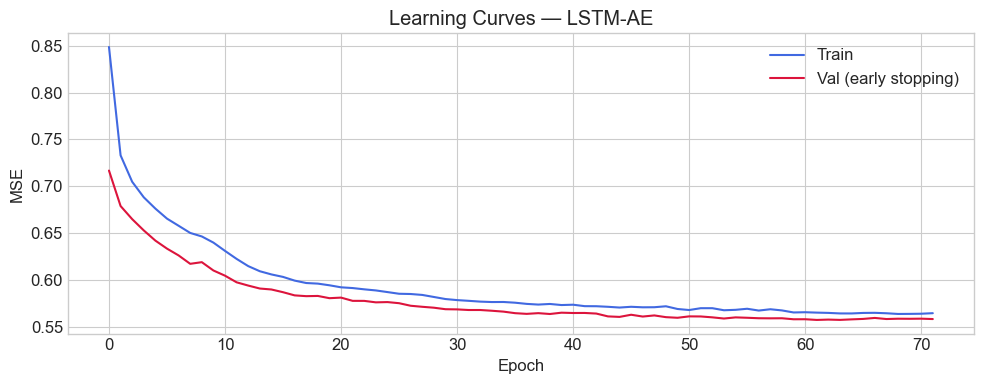

Best val_loss: 0.557505


In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history.history['loss'], 'royalblue', label='Train')
ax.plot(history.history['val_loss'], 'crimson', label='Val (early stopping)')
ax.set(xlabel='Epoch', ylabel='MSE', title='Learning Curves — LSTM-AE')
ax.legend()
plt.tight_layout()
plt.show()
print(f'Best val_loss: {min(history.history["val_loss"]):.6f}')

## 6. Calibration: Weighted MSE + Threshold

Same approach as NB04 v3: a per-feature MSE weighted by discriminative power (each feature's
individual AUC-ROC on the validation set). The advantage of the LSTM is that the temporal
reconstruction error amplifies the signal: a window containing a sustained attack produces high
error across *all* timesteps, not only on the most discriminative features.

In [8]:
def calibrate_threshold(y_true, scores, beta=1.0):

    precisions, recalls, thresholds = precision_recall_curve(y_true, scores)

    precisions = precisions[:-1]

    recalls    = recalls[:-1]

    fbeta = ((1 + beta**2) * precisions * recalls /

             (beta**2 * precisions + recalls + 1e-10))

    best_idx = np.argmax(fbeta)

    best_thr = thresholds[best_idx]

    n = len(thresholds)

    idx = np.linspace(0, n-1, min(500, n), dtype=int)

    results_df = pd.DataFrame({

        'threshold': thresholds[idx], 'precision': precisions[idx],

        'recall': recalls[idx],

        'f1': ((2*precisions*recalls)/(precisions+recalls+1e-10))[idx],

        'f2': ((5*precisions*recalls)/(4*precisions+recalls+1e-10))[idx],

    })

    return best_thr, fbeta[best_idx], results_df


# ── Per-feature MSE for each validation window ──

val_recon = lstm_ae.predict(X_val_w, batch_size=BATCH_SIZE, verbose=0)

# Shape (n_windows, 60, n_features); averaging over timesteps gives one MSE per feature

mse_per_feature_val = np.mean((X_val_w - val_recon)**2, axis=1)  # (n_windows, 14)


# ── Per-feature AUC-ROC, used to weight the features ──

print('Discriminative power per feature (AUC-ROC on val):')

feature_aucs = []

for j, fname in enumerate(feat_names):

    try:

        auc_j = roc_auc_score(y_val_w, mse_per_feature_val[:, j])

    except ValueError:

        auc_j = 0.5

    feature_aucs.append(auc_j)

    marker = ' <<<' if auc_j > 0.60 else ''

    print(f'  {fname:30s}  AUC={auc_j:.4f}{marker}')


feature_aucs = np.array(feature_aucs)

weights = np.maximum(feature_aucs - 0.5, 0)

weights = weights / (weights.sum() + 1e-10)


print()

print('Normalized weights (features with weight > 0.01):')

for j, fname in enumerate(feat_names):

    if weights[j] > 0.01:

        print(f'  {fname:30s}  w={weights[j]:.4f}')


# ── Final score: AUC-weighted sum of per-feature MSE ──

scores_val_w = np.sum(mse_per_feature_val * weights[None, :], axis=1)


# Same scoring on the test set

test_recon = lstm_ae.predict(X_test_w, batch_size=BATCH_SIZE, verbose=0)

mse_per_feature_test = np.mean((X_test_w - test_recon)**2, axis=1)

scores_test_w = np.sum(mse_per_feature_test * weights[None, :], axis=1)


# Calibrate the threshold

# ── iter1 change: calibrate on F1 (the reported metric is F1) ──

best_thr, best_f1_val, cal_df = calibrate_threshold(y_val_w, scores_val_w, beta=1.0)

_, best_f2_val, _ = calibrate_threshold(y_val_w, scores_val_w, beta=2.0)


print()

print(f'Score: weighted MSE (weighted by per-feature AUC)')

print(f'Optimal threshold (val, F1): {best_thr:.6f}')

print(f'  F1 on val: {best_f1_val:.4f}  (optimized)')

print(f'  F1 on val: {best_f1_val:.4f}')

Discriminative power per feature (AUC-ROC on val):
  Global_active_power             AUC=0.7512 <<<
  Global_reactive_power           AUC=0.7707 <<<
  Voltage                         AUC=0.7344 <<<
  Global_intensity                AUC=0.7285 <<<
  Sub_metering_1                  AUC=0.7767 <<<
  Sub_metering_2                  AUC=0.6462 <<<
  Sub_metering_3                  AUC=0.6115 <<<
  VI_residual                     AUC=0.9071 <<<
  hour_sin                        AUC=0.6805 <<<
  hour_cos                        AUC=0.6741 <<<
  dow_sin                         AUC=0.6532 <<<
  dow_cos                         AUC=0.6568 <<<
  gap_diff1                       AUC=0.5457
  vi_res_abs                      AUC=0.8119 <<<
  vi_res_roll15_mean              AUC=0.8625 <<<
  gap_intensity_ratio             AUC=0.9373 <<<
  sm_gap_ratio                    AUC=0.8498 <<<

Normalized weights (features with weight > 0.01):
  Global_active_power             w=0.0613
  Global_reactive_power   

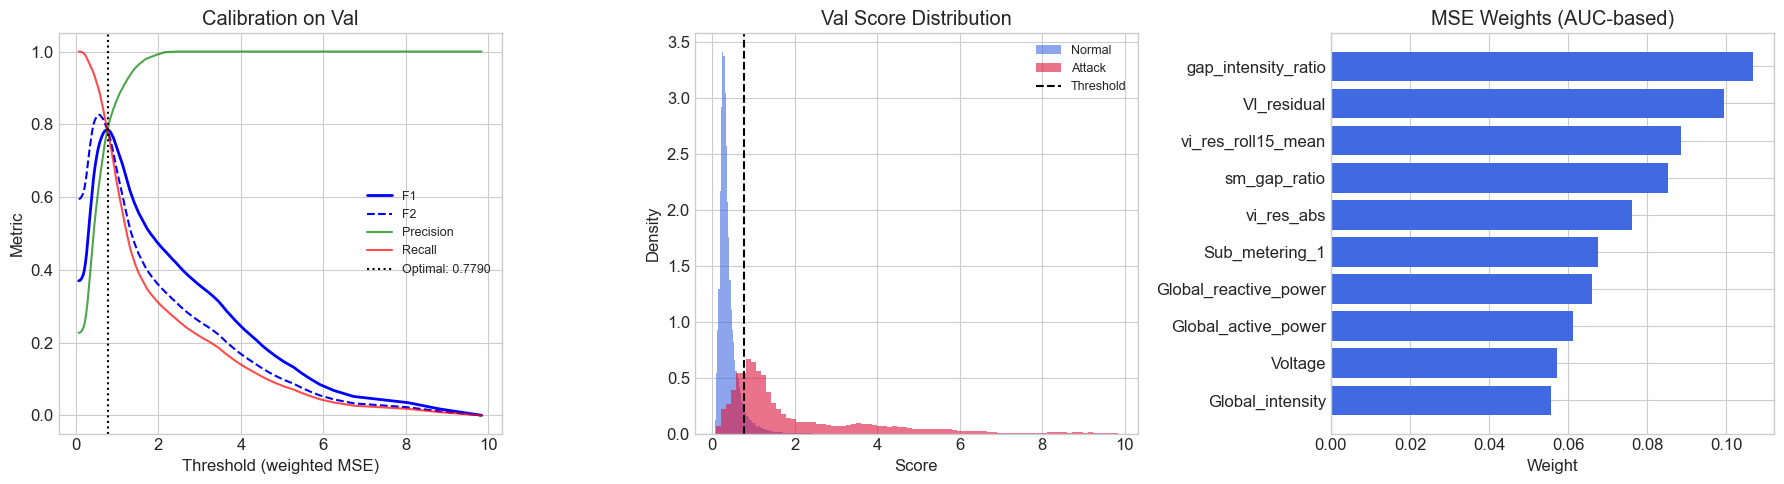

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
ax.plot(cal_df['threshold'], cal_df['f1'], 'b-', lw=2, label='F1')
ax.plot(cal_df['threshold'], cal_df['f2'], 'b--', lw=1.5, label='F2')
ax.plot(cal_df['threshold'], cal_df['precision'], 'g-', lw=1.5, label='Precision', alpha=0.7)
ax.plot(cal_df['threshold'], cal_df['recall'], 'r-', lw=1.5, label='Recall', alpha=0.7)
ax.axvline(best_thr, color='k', linestyle=':', lw=1.5, label=f'Optimal: {best_thr:.4f}')
ax.set(xlabel='Threshold (weighted MSE)', ylabel='Metric', title='Calibration on Val')
ax.legend(fontsize=9)

ax = axes[1]
ax.hist(scores_val_w[y_val_w == 0], bins=80, alpha=0.6, color='royalblue', label='Normal', density=True)
ax.hist(scores_val_w[y_val_w == 1], bins=80, alpha=0.6, color='crimson', label='Attack', density=True)
ax.axvline(best_thr, color='k', linestyle='--', lw=1.5, label='Threshold')
ax.set(xlabel='Score', ylabel='Density', title='Val Score Distribution')
ax.legend(fontsize=9)

ax = axes[2]
sorted_idx = np.argsort(weights)[::-1]
top_n = min(10, (weights > 0.01).sum())
top_idx = sorted_idx[:top_n]
ax.barh([feat_names[j] for j in top_idx], weights[top_idx], color='royalblue')
ax.set_xlabel('Weight')
ax.set_title('MSE Weights (AUC-based)')
ax.invert_yaxis()

plt.tight_layout()
plt.show()

## 7. RAW Evaluation (window level)

In [10]:
y_pred_w = (scores_test_w > best_thr).astype(int)

print('=' * 60)
print('METRICS — LSTM-AE (60 min window level)')
print('=' * 60)
print()
print(classification_report(y_test_w, y_pred_w, target_names=['Normal', 'Attack']))

f1   = f1_score(y_test_w, y_pred_w)
f2   = fbeta_score(y_test_w, y_pred_w, beta=2)
prec = precision_score(y_test_w, y_pred_w)
rec  = recall_score(y_test_w, y_pred_w)
auc_roc = roc_auc_score(y_test_w, scores_test_w)
auc_pr  = average_precision_score(y_test_w, scores_test_w)

print(f'AUC-ROC: {auc_roc:.4f}  |  AUC-PR: {auc_pr:.4f}')
print(f'F1: {f1:.4f}  |  F2: {f2:.4f}  |  Precision: {prec:.4f}  |  Recall: {rec:.4f}')

METRICS — LSTM-AE (60 min window level)

              precision    recall  f1-score   support

      Normal       0.94      0.95      0.94    460592
      Attack       0.83      0.80      0.82    144348

    accuracy                           0.91    604940
   macro avg       0.88      0.88      0.88    604940
weighted avg       0.91      0.91      0.91    604940

AUC-ROC: 0.9429  |  AUC-PR: 0.8853
F1: 0.8171  |  F2: 0.8097  |  Precision: 0.8297  |  Recall: 0.8048


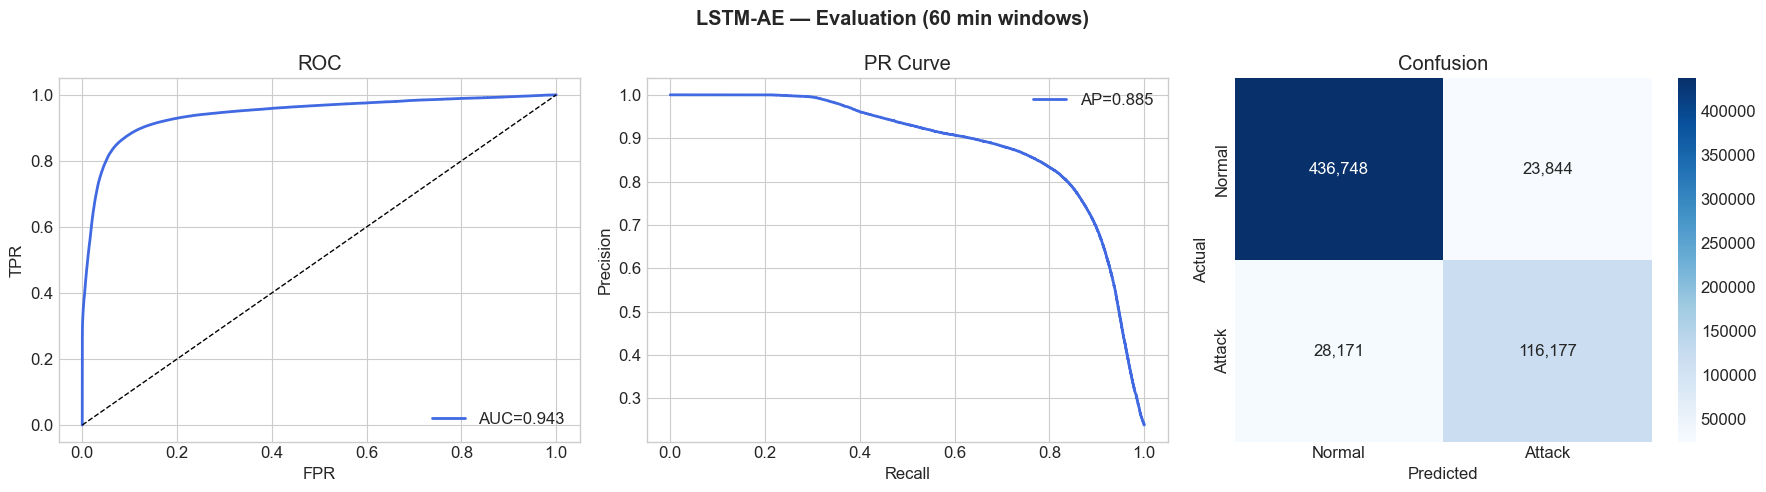

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

fpr, tpr, _ = roc_curve(y_test_w, scores_test_w)
axes[0].plot(fpr, tpr, 'royalblue', lw=2, label=f'AUC={auc_roc:.3f}')
axes[0].plot([0,1],[0,1],'k--', lw=1)
axes[0].set(xlabel='FPR', ylabel='TPR', title='ROC')
axes[0].legend()

pr_c, rc_c, _ = precision_recall_curve(y_test_w, scores_test_w)
axes[1].plot(rc_c, pr_c, 'royalblue', lw=2, label=f'AP={auc_pr:.3f}')
axes[1].set(xlabel='Recall', ylabel='Precision', title='PR Curve')
axes[1].legend()

cm = confusion_matrix(y_test_w, y_pred_w)
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', ax=axes[2],
            xticklabels=['Normal','Attack'], yticklabels=['Normal','Attack'])
axes[2].set(xlabel='Predicted', ylabel='Actual', title='Confusion')
plt.suptitle('LSTM-AE — Evaluation (60 min windows)', fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Window-to-Timestep Expansion + Temporal Voting

**v4 change:** expansion by **AVERAGE** instead of OR.

Previously, if any one of the 60 windows covering a timestep was positive, the timestep was marked
positive. This caused roughly 50K false positives, because a single score spike contaminated all
60 timesteps it touched.

Now each timestep score is the **mean** of the scores of every window covering it. An isolated
spike is diluted, whereas a sustained attack keeps the score high.

In [12]:
# ── v4 change: expand window scores to timesteps by AVERAGE (not OR) ──
# Old behaviour: y_pred_w[i]==1 set preds_per_ts[s:e]=1, so one window contaminated 60 timesteps.
# New behaviour: each timestep takes the mean score of all windows covering it.

n_test = len(X_test_scaled)
score_accumulator = np.zeros(n_test, dtype=np.float64)
score_count       = np.zeros(n_test, dtype=np.float64)

for i, s in enumerate(test_starts):
    e = min(s + WINDOW_SIZE, n_test)
    score_accumulator[s:e] += scores_test_w[i]
    score_count[s:e] += 1

score_count[score_count == 0] = 1  # guard against division by zero
scores_per_ts = score_accumulator / score_count

# Raw prediction: threshold the averaged score
preds_per_ts = (scores_per_ts > best_thr).astype(int)

# ── Same expansion on val, used to grid-search the temporal voting filter ──
n_val = len(X_val_scaled)
score_acc_val = np.zeros(n_val, dtype=np.float64)
score_cnt_val = np.zeros(n_val, dtype=np.float64)

for i, s in enumerate(val_starts):
    e = min(s + WINDOW_SIZE, n_val)
    score_acc_val[s:e] += scores_val_w[i]
    score_cnt_val[s:e] += 1

score_cnt_val[score_cnt_val == 0] = 1
scores_val_ts = score_acc_val / score_cnt_val
preds_val_ts = (scores_val_ts > best_thr).astype(int)

# ── Temporal voting ──
def temporal_vote_vectorized(y_pred, W, K):
    cum = np.concatenate([[0], np.cumsum(y_pred)])
    n = len(y_pred)
    ends = np.arange(1, n + 1)
    starts_v = np.maximum(0, ends - W)
    votes = cum[ends] - cum[starts_v]
    return (votes >= K).astype(int)

W_candidates = [3, 5, 7, 9, 11, 15, 21]
best_wk_f1, best_W, best_K = 0, 3, 2
grid_results = []

for W in W_candidates:
    for K in range(2, W + 1):
        y_sm = temporal_vote_vectorized(preds_val_ts, W, K)
        f1_sm = f1_score(y_val, y_sm)
        pr_sm = precision_score(y_val, y_sm, zero_division=0)
        rc_sm = recall_score(y_val, y_sm)
        grid_results.append({'W': W, 'K': K, 'f1': f1_sm,
                             'precision': pr_sm, 'recall': rc_sm})
        if f1_sm > best_wk_f1:
            best_wk_f1, best_W, best_K = f1_sm, W, K

grid_df = pd.DataFrame(grid_results)
best_row = grid_df.loc[grid_df['f1'].idxmax()]
print(f'Best (W,K): W={best_W}, K={best_K}')
print(f'  F1={best_row["f1"]:.4f}  P={best_row["precision"]:.4f}  R={best_row["recall"]:.4f}')

# Apply the best (W, K) to the test set
y_pred_smooth = temporal_vote_vectorized(preds_per_ts, best_W, best_K)

f1_s   = f1_score(y_test, y_pred_smooth)
f2_s   = fbeta_score(y_test, y_pred_smooth, beta=2)
prec_s = precision_score(y_test, y_pred_smooth)
rec_s  = recall_score(y_test, y_pred_smooth)

print()
print('=' * 70)
print('COMPARISON — LSTM-AE v4: RAW (timestep) vs TEMPORAL VOTING')
print('=' * 70)
raw_f1_ts  = f1_score(y_test, preds_per_ts)
raw_pr_ts  = precision_score(y_test, preds_per_ts)
raw_rc_ts  = recall_score(y_test, preds_per_ts)
raw_f2_ts  = fbeta_score(y_test, preds_per_ts, beta=2)
print()
print(f'  {"Metric":12s} {"Raw":>10s} {"Smoothed":>10s} {"Delta":>10s}')
print('  ' + '-' * 45)
for name, raw_v, sm_v in [
    ('F1',        raw_f1_ts, f1_s),
    ('F2',        raw_f2_ts, f2_s),
    ('Precision',  raw_pr_ts, prec_s),
    ('Recall',     raw_rc_ts, rec_s),
]:
    delta = sm_v - raw_v
    print(f'  {name:12s} {raw_v:>10.4f} {sm_v:>10.4f} {delta:>+10.4f}')
print()
print(f'  Filter: W={best_W}, K={best_K}')
print(f'  Expansion: AVERAGE (v4, previously OR)')
print()
print(classification_report(y_test, y_pred_smooth, target_names=['Normal', 'Attack']))

# ── iter1 lever A: joint search over (threshold, W, K) on val ──
# The earlier calibration picks the threshold by F1 at the WINDOW level, but the reported
# metric is F1 at the smoothed TIMESTEP level. We run a joint grid over val to pick the
# (threshold, W, K) that maximises smoothed timestep F1, i.e. the true objective.

print()
print('=' * 60)
print('JOINT SEARCH (threshold × W × K) over val — lever A iter1')
print('=' * 60)

# 60 threshold candidates drawn from quantiles of the window-level PR curve
prc_pr_, prc_rc_, prc_thr_ = precision_recall_curve(y_val_w, scores_val_w)
prc_thr_ = prc_thr_[prc_thr_ > 0]
if len(prc_thr_) < 5:
    thr_candidates = np.linspace(scores_val_w.min(), scores_val_w.max(), 30)
else:
    thr_candidates = np.unique(np.quantile(
        prc_thr_, np.linspace(0.30, 0.999, 60)))

W_grid = [3, 5, 7, 9, 11, 15, 21, 31, 45, 60]
best_joint_f1 = -1.0
best_joint = (best_thr, best_W, best_K)
n_evals = 0

for thr in thr_candidates:
    preds_val_ts_local = (scores_val_ts > thr).astype(int)
    if preds_val_ts_local.sum() == 0 or preds_val_ts_local.sum() == len(preds_val_ts_local):
        continue
    for W in W_grid:
        for K in range(2, W + 1):
            y_sm = temporal_vote_vectorized(preds_val_ts_local, W, K)
            if y_sm.sum() == 0:
                continue
            f1_sm = f1_score(y_val, y_sm)
            n_evals += 1
            if f1_sm > best_joint_f1:
                best_joint_f1 = f1_sm
                best_joint = (thr, W, K)

print(f'  Evaluations: {n_evals}')
print(f'  Best val smoothed F1 (joint): {best_joint_f1:.4f}')
print(f'  Combination: thr={best_joint[0]:.6f}, W={best_joint[1]}, K={best_joint[2]}')
print(f'  Before (W,K only): F1 val={best_row["f1"]:.4f}, W={best_W}, K={best_K}')

# Adopt the joint result only if it improves val F1 (the contract: tune on val only)
if best_joint_f1 > best_row['f1']:
    best_thr, best_W, best_K = best_joint
    preds_per_ts = (scores_per_ts > best_thr).astype(int)
    preds_val_ts = (scores_val_ts > best_thr).astype(int)
    print(f'  -> Adopting joint: thr={best_thr:.6f}, W={best_W}, K={best_K}')
else:
    print('  -> Keeping prior calibration (joint does not improve).')

# Re-evaluate the test set with the final (best_thr, best_W, best_K)
y_pred_smooth = temporal_vote_vectorized(preds_per_ts, best_W, best_K)

f1_s   = f1_score(y_test, y_pred_smooth)
f2_s   = fbeta_score(y_test, y_pred_smooth, beta=2)
prec_s = precision_score(y_test, y_pred_smooth)
rec_s  = recall_score(y_test, y_pred_smooth)
raw_f1_ts  = f1_score(y_test, preds_per_ts)
raw_pr_ts  = precision_score(y_test, preds_per_ts)
raw_rc_ts  = recall_score(y_test, preds_per_ts)
raw_f2_ts  = fbeta_score(y_test, preds_per_ts, beta=2)

print()
print(f'TEST after joint:  F1_smoothed={f1_s:.4f}  P={prec_s:.4f}  R={rec_s:.4f}')
print('=' * 60)

Best (W,K): W=9, K=9
  F1=0.7069  P=0.6040  R=0.8520

COMPARISON — LSTM-AE v4: RAW (timestep) vs TEMPORAL VOTING

  Metric              Raw   Smoothed      Delta
  ---------------------------------------------
  F1               0.7184     0.7250    +0.0066
  F2               0.8150     0.8079    -0.0071
  Precision        0.5998     0.6191    +0.0192
  Recall           0.8953     0.8746    -0.0207

  Filter: W=9, K=9
  Expansion: AVERAGE (v4, previously OR)

              precision    recall  f1-score   support

      Normal       0.97      0.90      0.93    508282
      Attack       0.62      0.87      0.72     96717

    accuracy                           0.89    604999
   macro avg       0.80      0.89      0.83    604999
weighted avg       0.92      0.89      0.90    604999


JOINT SEARCH (threshold × W × K) over val — lever A iter1
  Evaluations: 11820
  Best val smoothed F1 (joint): 0.7203
  Combination: thr=0.895621, W=3, K=3
  Before (W,K only): F1 val=0.7069, W=9, K=9
  -> Ad

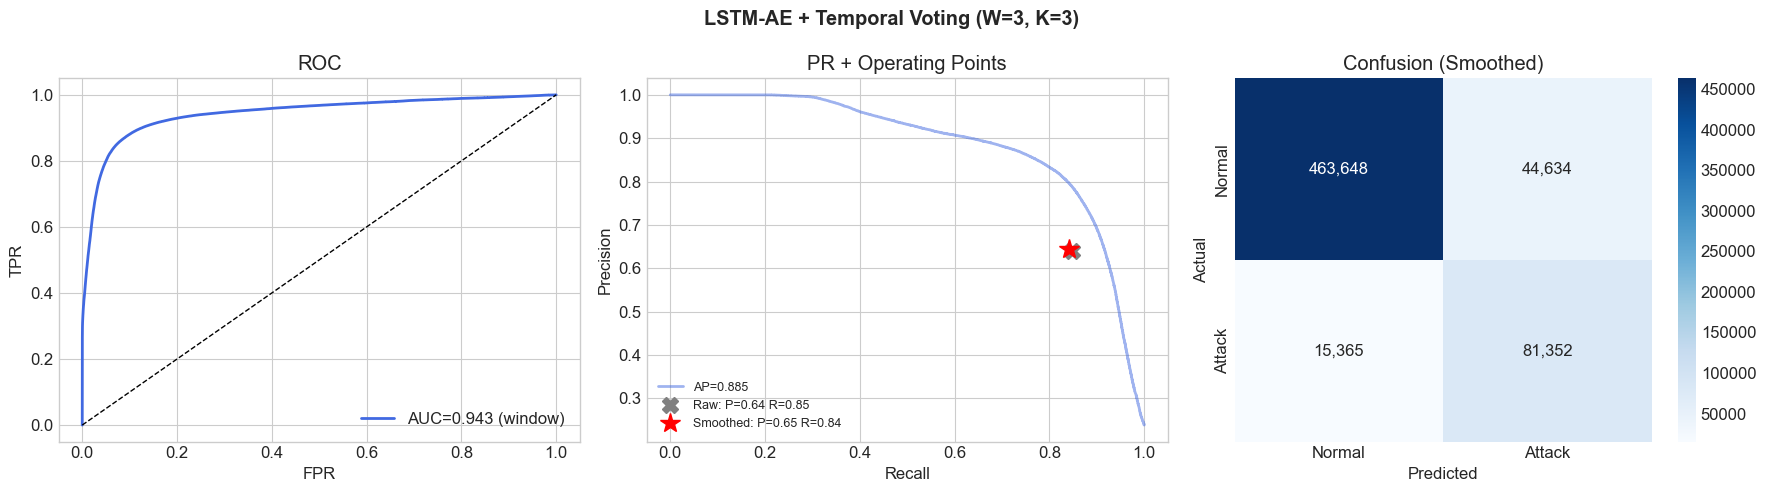

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(fpr, tpr, 'royalblue', lw=2, label=f'AUC={auc_roc:.3f} (window)')
axes[0].plot([0,1],[0,1],'k--', lw=1)
axes[0].set(xlabel='FPR', ylabel='TPR', title='ROC')
axes[0].legend()

axes[1].plot(rc_c, pr_c, 'royalblue', lw=2, label=f'AP={auc_pr:.3f}', alpha=0.5)
axes[1].plot(raw_rc_ts, raw_pr_ts, 'X', color='gray', markersize=12,
             label=f'Raw: P={raw_pr_ts:.2f} R={raw_rc_ts:.2f}')
axes[1].plot(rec_s, prec_s, '*', color='red', markersize=15,
             label=f'Smoothed: P={prec_s:.2f} R={rec_s:.2f}')
axes[1].set(xlabel='Recall', ylabel='Precision', title='PR + Operating Points')
axes[1].legend(fontsize=9)

cm_s = confusion_matrix(y_test, y_pred_smooth)
sns.heatmap(cm_s, annot=True, fmt=',d', cmap='Blues', ax=axes[2],
            xticklabels=['Normal','Attack'], yticklabels=['Normal','Attack'])
axes[2].set(xlabel='Predicted', ylabel='Actual', title='Confusion (Smoothed)')
plt.suptitle(f'LSTM-AE + Temporal Voting (W={best_W}, K={best_K})', fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Recall by Type x Severity (Smoothed)

Recall by type x severity:
  Type                     N      Low      Med     High    Total
  -------------------------------------------------------
  scaling             13,449    0.438    0.914    0.998    0.796
  offset              13,898    0.678    0.969    0.994    0.895
  noise               14,357    1.000    1.000    1.000    1.000
  ramp                14,006    0.445    0.636    0.780    0.618
  step                13,731    0.582    0.798    0.780    0.725
  replay              14,084    0.774    0.912    0.991    0.895
  voltage_spoof       13,192    0.862    1.000    1.000    0.957


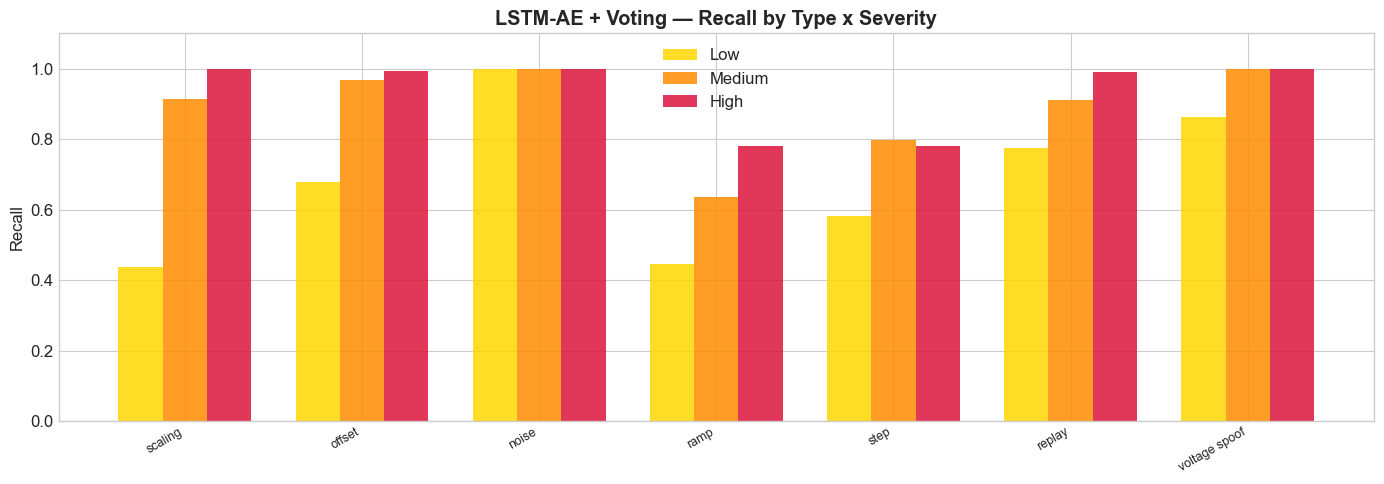

In [14]:
def recall_by_type_severity(attack_types_col, severity_col, y_true, y_pred,
                            attack_types_list, title_prefix):
    print(f'Recall by type x severity:')
    print(f'  {"Type":18s} {"N":>7s} {"Low":>8s} {"Med":>8s} {"High":>8s} {"Total":>8s}')
    print('  ' + '-' * 55)
    recall_data = {}
    for t in attack_types_list:
        mask_t = (attack_types_col == t)
        n_t = (mask_t & (y_true == 1)).sum()
        row = f'  {t:18s} {n_t:>7,}'
        for sev in ['low', 'medium', 'high']:
            mask = mask_t & (severity_col == sev) & (y_true == 1)
            n = mask.sum()
            if n > 0:
                r = (y_pred[mask] == 1).sum() / n
                row += f' {r:>8.3f}'
            else:
                r = np.nan
                row += f' {"--":>8s}'
            recall_data[(t, sev)] = r
        mask_all = mask_t & (y_true == 1)
        n_all = mask_all.sum()
        r_t = (y_pred[mask_all] == 1).sum() / n_all if n_all > 0 else 0
        row += f' {r_t:>8.3f}'
        print(row)

    fig, ax = plt.subplots(figsize=(14, 5))
    x = np.arange(len(attack_types_list))
    w = 0.25
    sev_colors = {'low': '#FFD700', 'medium': '#FF8C00', 'high': '#DC143C'}
    for i, (sev, c) in enumerate(sev_colors.items()):
        vals = [recall_data.get((t, sev), 0) for t in attack_types_list]
        vals = [v if not (isinstance(v, float) and np.isnan(v)) else 0 for v in vals]
        ax.bar(x + i * w, vals, w, label=sev.capitalize(), color=c, alpha=0.85)
    ax.set_xticks(x + w)
    ax.set_xticklabels([t.replace('_', ' ') for t in attack_types_list],
                        rotation=30, ha='right', fontsize=9)
    ax.set_ylabel('Recall'); ax.set_ylim(0, 1.1)
    ax.set_title(f'{title_prefix} — Recall by Type x Severity', fontweight='bold')
    ax.legend()
    plt.tight_layout(); plt.show()
    return recall_data

recall_data = recall_by_type_severity(
    df_test['attack_type'].values, df_test['severity'].values,
    y_test, y_pred_smooth, ATTACK_TYPES, 'LSTM-AE + Voting')

## 10. Detection Latency (Smoothed)

In [15]:
def compute_detection_latency(df_preds, score_col, threshold):
    results = []
    attacked = df_preds[df_preds['episode_id'] >= 0]
    for ep_id, group in attacked.groupby('episode_id'):
        group = group.sort_index()
        detections = group[group[score_col] > threshold]
        ep_start = group.index[0]
        results.append({
            'episode_id': ep_id, 'type': group['attack_type'].iloc[0],
            'severity': group['severity'].iloc[0], 'duration_min': len(group),
            'latency_min': ((detections.index[0] - ep_start).total_seconds() / 60
                            if len(detections) > 0 else np.nan),
            'detected': len(detections) > 0
        })
    return pd.DataFrame(results)

def print_latency_summary(lat_df):
    det_rate = lat_df['detected'].mean()
    detected = lat_df[lat_df['detected']]
    med_lat  = detected['latency_min'].median() if len(detected) > 0 else np.nan
    print(f'Detection per episode: {det_rate:.1%} ({lat_df["detected"].sum()}/{len(lat_df)})')
    if not np.isnan(med_lat):
        print(f'Median latency:        {med_lat:.1f} min')
    print()
    for sev in ['low', 'medium', 'high']:
        sub = lat_df[lat_df['severity'] == sev]
        if len(sub) == 0: continue
        det = sub['detected'].mean()
        det_sub = sub[sub['detected']]
        lat = det_sub['latency_min'].median() if len(det_sub) > 0 else np.nan
        lat_s = f'{lat:.1f} min' if not np.isnan(lat) else 'N/A'
        print(f'  {sev:8s}: detection {det:.0%}  |  median latency {lat_s}')
    return det_rate, med_lat

df_test_scored = df_test.copy()
df_test_scored['lstm_pred_smooth'] = y_pred_smooth.astype(float)
lat_df = compute_detection_latency(df_test_scored, 'lstm_pred_smooth', 0.5)
det_rate, med_lat = print_latency_summary(lat_df)

Detection per episode: 95.4% (801/840)
Median latency:        0.0 min

  low     : detection 85%  |  median latency 0.0 min
  medium  : detection 100%  |  median latency 0.0 min
  high    : detection 100%  |  median latency 0.0 min


## 11. Edge Computing + Saving

In [16]:
model_path = os.path.join(DATA_DIR, 'model_lstm_autoencoder.keras')
try:
    lstm_ae.save(model_path)
except Exception:
    model_path = os.path.join(DATA_DIR, 'model_lstm_autoencoder.h5')
    lstm_ae.save(model_path)
size_kb = os.path.getsize(model_path) / 1e3

joblib.dump(scaler, os.path.join(DATA_DIR, 'scaler_lstm_autoencoder.pkl'))
np.save(os.path.join(DATA_DIR, 'feature_weights_lstm_ae.npy'), weights)

_ = lstm_ae.predict(X_test_w[:10], batch_size=BATCH_SIZE, verbose=0)
times = []
for _ in range(5):
    t0 = time.time()
    lstm_ae.predict(X_test_w[:1000], batch_size=BATCH_SIZE, verbose=0)
    times.append(time.time() - t0)
ms_win_avg = np.mean(times) / 1000 * 1000
ms_smp_avg = ms_win_avg / WINDOW_SIZE

print('=' * 55)
print('EDGE COMPUTING — LSTM-AE + TEMPORAL VOTING')
print('=' * 55)
print(f'  Parameters:       {lstm_ae.count_params():,}')
print(f'  Scoring:          weighted MSE ({(weights>0.01).sum()} active features)')
print(f'  Filter:           W={best_W}, K={best_K}')
print(f'  Size on disk:     {size_kb:.1f} KB')
print(f'  Window latency:   {ms_win_avg:.2f} ms (60 min of data)')
print(f'  Equiv latency:    {ms_smp_avg:.4f} ms/sample')
print(f'  Training:         {t_train:.1f} s ({t_train/60:.1f} min)')

df_out = df_test.copy()
df_out['lstm_score'] = scores_per_ts
df_out['lstm_pred_raw']    = preds_per_ts
df_out['lstm_pred_smooth'] = y_pred_smooth
df_out.to_csv(os.path.join(DATA_DIR, 'predictions_lstm_autoencoder.csv'))
np.save(os.path.join(DATA_DIR, 'threshold_lstm_ae.npy'), np.array([best_thr]))
lat_df.to_csv(os.path.join(DATA_DIR, 'latency_lstm_autoencoder.csv'), index=False)

metrics = {
    'model': 'LSTM-Autoencoder + Temporal Voting',
    'feature_mode': 'medium + vi_res_abs',
    'scoring': 'weighted_mse',
    'raw_f1': round(raw_f1_ts, 4), 'raw_f2': round(raw_f2_ts, 4),
    'raw_precision': round(raw_pr_ts, 4), 'raw_recall': round(raw_rc_ts, 4),
    'f1': round(f1_s, 4), 'f2': round(f2_s, 4),
    'precision': round(prec_s, 4), 'recall': round(rec_s, 4),
    'auc_roc': round(auc_roc, 4), 'auc_pr': round(auc_pr, 4),
    'threshold': round(float(best_thr), 8),
    'temporal_W': best_W, 'temporal_K': best_K,
    'model_size_kb': round(size_kb, 1),
    'ms_per_window': round(ms_win_avg, 4), 'ms_per_sample': round(ms_smp_avg, 4),
    'n_params': lstm_ae.count_params(), 'n_features': n_features, 'bottleneck': 16,
    'window_size': WINDOW_SIZE, 'train_step': TRAIN_STEP,
    'train_time_s': round(t_train, 1),
    'detection_rate': round(det_rate, 4),
    'median_latency_min': round(float(med_lat), 1) if not np.isnan(med_lat) else None,
    'granularity': f'{WINDOW_SIZE} min window, 1 min output',
    'feature_names': feat_names,
    'feature_weights': {fn: round(float(w), 4) for fn, w in zip(feat_names, weights) if w > 0.01},
}
with open(os.path.join(DATA_DIR, 'metrics_lstm_autoencoder.json'), 'w') as f:
    json.dump(metrics, f, indent=2)

print()
print('Saved in data/:')
for fn in ['predictions_lstm_autoencoder.csv', 'metrics_lstm_autoencoder.json',
           'model_lstm_autoencoder.keras', 'scaler_lstm_autoencoder.pkl',
           'feature_weights_lstm_ae.npy', 'threshold_lstm_ae.npy',
           'latency_lstm_autoencoder.csv']:
    print(f'  * {fn}')

EDGE COMPUTING — LSTM-AE + TEMPORAL VOTING
  Parameters:       259,289
  Scoring:          weighted MSE (17 active features)
  Filter:           W=3, K=3
  Size on disk:     3178.6 KB
  Window latency:   0.23 ms (60 min of data)
  Equiv latency:    0.0038 ms/sample
  Training:         522.2 s (8.7 min)

Saved in data/:
  * predictions_lstm_autoencoder.csv
  * metrics_lstm_autoencoder.json
  * model_lstm_autoencoder.keras
  * scaler_lstm_autoencoder.pkl
  * feature_weights_lstm_ae.npy
  * threshold_lstm_ae.npy
  * latency_lstm_autoencoder.csv


## 12. Summary

### Advantages of the LSTM autoencoder over IF and Dense-AE

| Aspect | IF | Dense-AE | LSTM-AE |
|---------|-----|----------|---------|
| Temporal context | None (point by point) | None | **60 min of sequence** |
| Compression | N/A | 14:3 = 4.7:1 | 840:16 = **52:1** |
| Temporal signal | Blind to trends | Blind to trends | Learns normal temporal patterns |
| Scoring | IF score | weighted MSE | weighted MSE + temporal |

### Why it is expected to outperform the others

The LSTM autoencoder has a fundamental advantage: it compresses 60 minutes x 14 features into just
16 values. If a 90-minute FDI episode distorts 30 of the 60 minutes inside a window, the compressed
representation cannot absorb the distortion, producing high MSE across the whole reconstruction
rather than on the attacked features alone.

The point-by-point models (IF, Dense-AE) see each minute in isolation. The LSTM sees the full
context: a value held low for 60 minutes at 3 p.m. is anomalous in a way that no minute-by-minute
model can detect.